In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/inpainting_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_inpainting as get_results, get_results_zero_latency

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
times_before = [0.5, 1, 4, 7, 14]

results_noremoval = get_results(
    f"results/data_runs_focused_noremoval.hdf",
)
results_varremoval = get_results(
    f"results/data_runs_focused_varied_removal.hdf",
)

results_2hrremoval = get_results(
    f"results/data_runs_psd_estimate.hdf",
)


In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

In [4]:
# Some definitions for when signals are removed

signals_in_region = [2,3,4,5]
removal_time_s = [7200, 11*86400, 14*86400, 7200]

## Variable removal and no removal - same plot

This is quite hard to see on the same plot, so we show the same things separately in the next cells

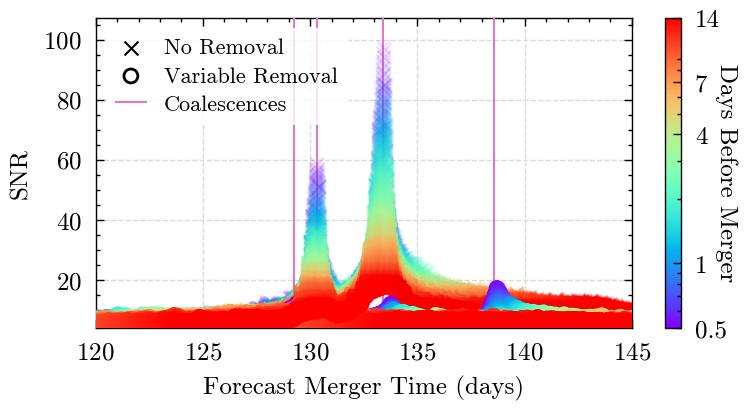

In [5]:
fig_focused_predict, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    results_two=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='No Removal',
    label_two='Variable Removal',
    alpha_one=0.1,
    start_time_offset=120,
    end_time_offset=145,
    width_factor=1.25
)


## Variable removal - predicted time

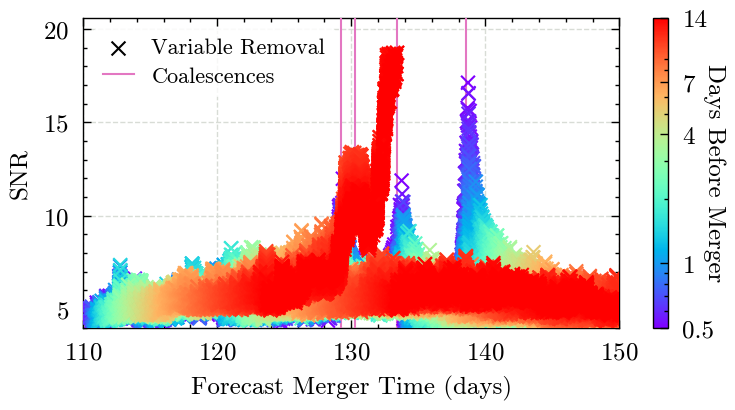

In [6]:
fig_focused_var_predicted, _ = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Variable Removal',
    start_time_offset=110,
    end_time_offset=150,
    width_factor=1.25
)

## Variable removal - end time 

(A better, labelled, version of this is made later to appear in the paper)

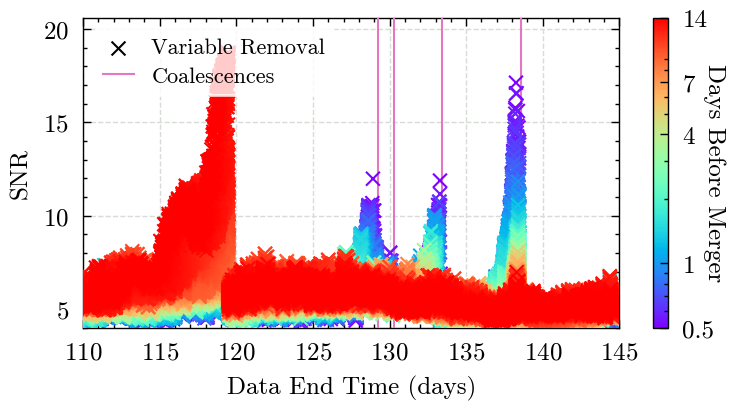

In [7]:
fig_focused_var_end_time, _ = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Variable Removal',
    predicted_time=False,
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.25
)

## No removal - predicted time

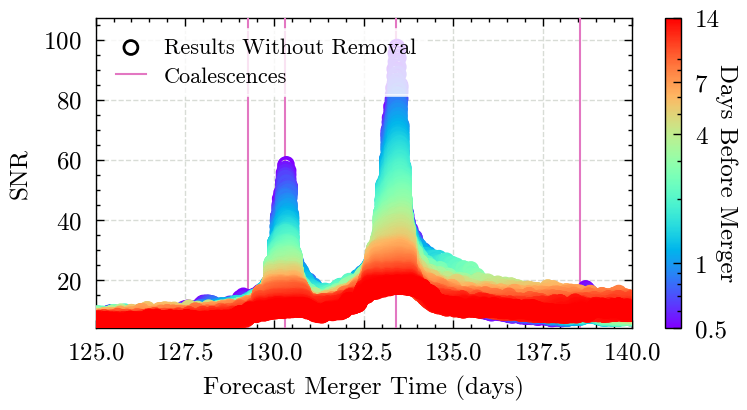

In [8]:
fig_focused_no_predicted, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Results Without Removal',
    marker_one='o',
    start_time_offset=125,
    end_time_offset=140,
    width_factor=1.25
)

## No removal - data end time

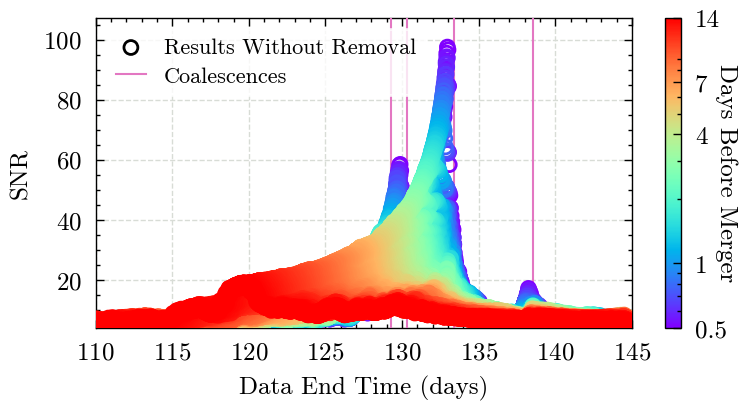

In [9]:
fig_focused_no_dataend, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Results Without Removal',
    predicted_time=False,
    marker_one='o',
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.25
)

## Removal 2 hours before merger - predicted time

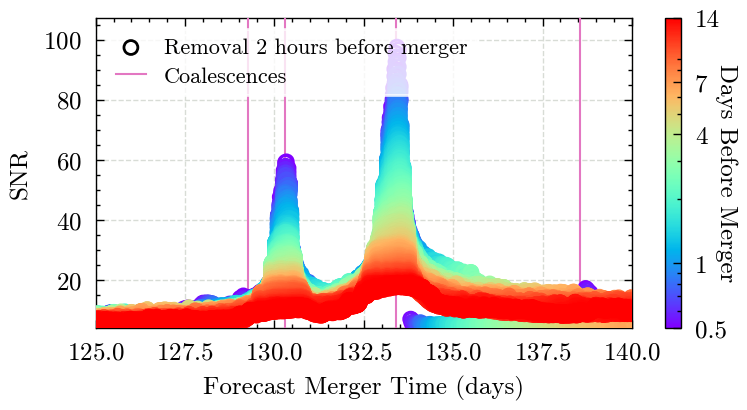

In [10]:
fig_focused_2hr_predicted, _ = plotting_utils.plot_around_time(
    results_one=results_2hrremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Removal 2 hours before merger',
    marker_one='o',
    start_time_offset=125,
    end_time_offset=140,
    width_factor=1.25
)

## Removal 2 hours before merger - data end time

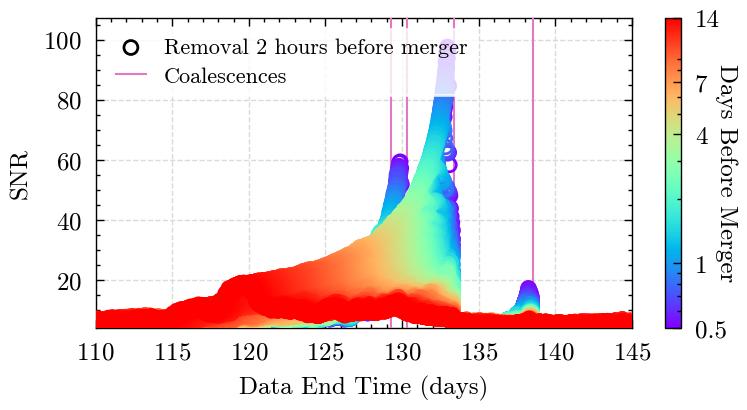

In [11]:
fig_focused_2hr_dataend, _ = plotting_utils.plot_around_time(
    results_one=results_2hrremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Removal 2 hours before merger',
    predicted_time=False,
    marker_one='o',
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.25
)

# The focused region section main plot - variable removal end times, with labels

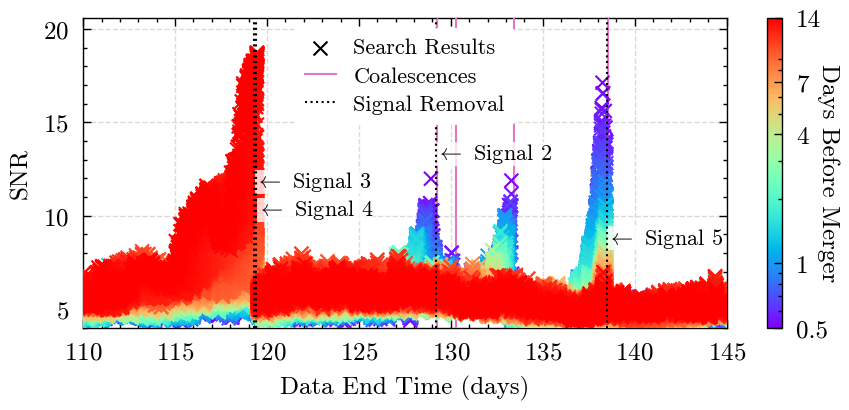

In [12]:
fig_focused_dataend, (ax_focused_dataend, labels, lines) = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Search Results',
    predicted_time=False,
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.5
)
# Add lines for when the signals are removed from the data
lines.append(ax_focused_dataend.axvline(
    0,
    c='k',
    linestyle=':'
))
labels.append('Signal Removal')
# ax_focused_dataend.legend(loc='upper left')
for signal_number, time_before in zip(signals_in_region, removal_time_s):
    ax_focused_dataend.axvline(
        (truth_times_s[signal_number] - time_before) / 86400,
        c='k',
        linestyle=':',
        zorder=100
    )
    ax_focused_dataend.text(
        (truth_times_s[signal_number] - time_before + 1800) / 86400,
        16-signal_number*1.5,
        f'$\leftarrow$ Signal {signal_number}', 
        fontsize=8,
        zorder=40,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none',boxstyle='square,pad=0')
    )
leg = ax_focused_dataend.legend(
    handles=lines,
    labels=labels,
    loc='upper center',
    framealpha=1,
    frameon=True,
)
leg.set_zorder(150)
fig_focused_dataend.savefig(f'plots/focused_results_data_end_time.pdf')
fig_focused_dataend.savefig(f'{paper_plots_dir}/figure_X_focused_region_variable_removal.png')

## Make a table of removed times (days) to be added to the paper

In [13]:
table_str = """\\begin{tabular}{|cc|cc|}
\\hline
\\multicolumn{2}{|c|}{Signal} & \\multicolumn{2}{c|}{Removal Time} \\\\
\\hline
Number & Time (days) & Offset & Time (days) \\\\
\\hline
"""
for signal_number, time_before in zip(signals_in_region, removal_time_s):
    if time_before > 86400:
        removal_time_str = f"{time_before / 86400:.0f} days"
    else:
        removal_time_str = f"{time_before / 3600:.0f} hours"
    truth_time_days = truth_times_s[signal_number] / 86400
    table_str += f"{signal_number} & {truth_time_days:.1f} & {removal_time_str} & {truth_time_days - time_before/86400:.1f} \\\\\n"
table_str += """\\hline
\\end{tabular}
"""

print(table_str)
with open('../../paper/tables/focused_removal_times.tex', 'w') as frt_table:
    frt_table.write(table_str)


\begin{tabular}{|cc|cc|}
\hline
\multicolumn{2}{|c|}{Signal} & \multicolumn{2}{c|}{Removal Time} \\
\hline
Number & Time (days) & Offset & Time (days) \\
\hline
2 & 129.3 & 2 hours & 129.2 \\
3 & 130.3 & 11 days & 119.3 \\
4 & 133.4 & 14 days & 119.4 \\
5 & 138.6 & 2 hours & 138.5 \\
\hline
\end{tabular}



Now make some statements about the relative times when a signal is removed, e.g. signal N is removed x days before/after signal M merges

In [14]:

for signal_number_1, time_before_1 in zip(signals_in_region, removal_time_s):
    for signal_number_2, time_before_2 in zip(signals_in_region, removal_time_s):
        offset_merger = (truth_times_s[signal_number_2]) - (truth_times_s[signal_number_1] - time_before_1)
        if offset_merger < 0:
            offset_merger_removed_str = f'{-offset_merger / 86400:.2f} days after'
        else:
            offset_merger_removed_str = f'{offset_merger / 86400:.2f} days before'
        print(f"Signal {signal_number_1} is removed {offset_merger_removed_str} signal {signal_number_2} merges")
        if signal_number_1 >= signal_number_2: continue
        offset = (truth_times_s[signal_number_2] - time_before_2) - (truth_times_s[signal_number_1] - time_before_1)
        if offset < 0:
            offset_removed_str = f'{-offset / 86400:.2f} days after'
        else:
            offset_removed_str = f'{offset / 86400:.2f} days before'
        print(f"Signal {signal_number_1} is removed {offset_removed_str} signal {signal_number_2} is removed")


Signal 2 is removed 0.08 days before signal 2 merges
Signal 2 is removed 1.13 days before signal 3 merges
Signal 2 is removed 9.87 days after signal 3 is removed
Signal 2 is removed 4.24 days before signal 4 merges
Signal 2 is removed 9.76 days after signal 4 is removed
Signal 2 is removed 9.38 days before signal 5 merges
Signal 2 is removed 9.30 days before signal 5 is removed
Signal 3 is removed 9.95 days before signal 2 merges
Signal 3 is removed 11.00 days before signal 3 merges
Signal 3 is removed 14.11 days before signal 4 merges
Signal 3 is removed 0.11 days before signal 4 is removed
Signal 3 is removed 19.25 days before signal 5 merges
Signal 3 is removed 19.16 days before signal 5 is removed
Signal 4 is removed 9.84 days before signal 2 merges
Signal 4 is removed 10.89 days before signal 3 merges
Signal 4 is removed 14.00 days before signal 4 merges
Signal 4 is removed 19.14 days before signal 5 merges
Signal 4 is removed 19.06 days before signal 5 is removed
Signal 5 is remo

# Gaps

Now we think about gaps - lets imagine that there are gaps before signal zero. Inpainting rides them out, the zero latency filter doesn't.

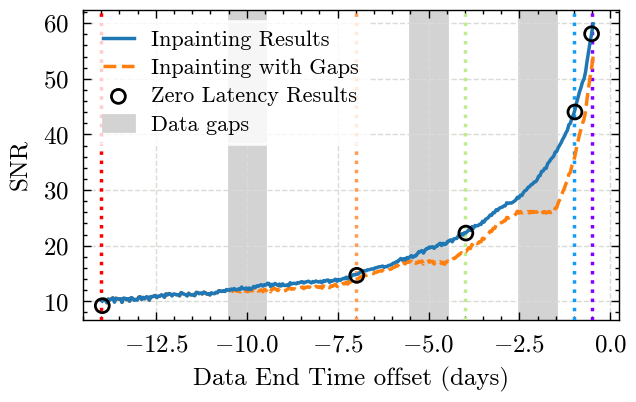

In [15]:
import numpy as np


# For signal zero - plot the results filtered for the closest to the predicted merger time
example_signal = 0

# Get the zero-latency results for this signal
results_zero_latency = get_results_zero_latency(
    "../zero_latency/results/psd_estimate/data_runs_raw_{time_before}_results.hdf",
    times_before
)

results_estimate_all = get_results(
    f"results/data_runs_psd_estimate.hdf"
)

# Filter the zero latency results to only use the closest point for each

zl_results_data_end_time = []
zl_results_snr = []

for t_before in times_before:
    this_t = results_zero_latency['time_before'] == t_before
    closest_match = np.argmin(
        abs(results_zero_latency['time'][this_t] - truth_times_s[example_signal])
    )
    zl_results_data_end_time.append(results_zero_latency['data_end_time'][this_t][closest_match])
    zl_results_snr.append(results_zero_latency['snr'][this_t][closest_match])

zl_results_data_end_time = np.array(zl_results_data_end_time)
zl_results_snr = np.array(zl_results_snr)

ip_times_before = np.unique(results_estimate_all['time_before'])
ip_results_data_end_time = []
ip_results_snr = []
for t_before in ip_times_before:
    this_t = results_estimate_all['time_before'] == t_before
    closest_match = np.argmin(
        abs(results_estimate_all['time'][this_t] - truth_times_s[example_signal])
    )
    ip_results_data_end_time.append(results_estimate_all['data_end_time'][this_t][closest_match])
    ip_results_snr.append(results_estimate_all['snr'][this_t][closest_match])

ip_results_data_end_time = np.array(ip_results_data_end_time)
ip_results_snr = np.array(ip_results_snr)

inpainting_gaps_results = get_results(
    "results/data_runs_signal_0_gaps.hdf",
)
ipg_times_before = np.unique(inpainting_gaps_results['time_before'])
ipg_results_data_end_time = []
ipg_results_snr = []
for t_before in ip_times_before:
    this_t = inpainting_gaps_results['time_before'] == t_before
    closest_match = np.argmin(
        abs(inpainting_gaps_results['time'][this_t] - truth_times_s[example_signal])
    )
    ipg_results_data_end_time.append(inpainting_gaps_results['data_end_time'][this_t][closest_match])
    ipg_results_snr.append(inpainting_gaps_results['snr'][this_t][closest_match])

ipg_results_data_end_time = np.array(ipg_results_data_end_time)
ipg_results_snr = np.array(ipg_results_snr)

width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1]

fig, ax = plt.subplots(1, figsize=(width, height),)

ax.plot(
    (ip_results_data_end_time - truth_times_s[example_signal]) / 86400,
    ip_results_snr,
    linewidth=1.25,
    color='tab:blue',
    label='Inpainting Results',
    zorder=10
)
ax.plot(
    (ipg_results_data_end_time - truth_times_s[example_signal]) / 86400,
    ipg_results_snr,
    linewidth=1.25,
    color='tab:orange',
    linestyle='--',
    label='Inpainting with Gaps',
    zorder=8
)

ax.scatter(
    (zl_results_data_end_time - truth_times_s[example_signal]) / 86400,
    zl_results_snr,
    edgecolor='k',
    marker='o',
    facecolors='none',
    label='Zero Latency Results',
    zorder=20

)

sm = plotting_utils.get_sm(vmin=min(times_before), vmax=max(times_before))

for time_before in times_before:
    ax.axvline(
        -time_before,
        c=sm.to_rgba(time_before),
        linestyle=':',
        linewidth=1.25,
        zorder=5
    )

for gap in [(2.5, 1.5), (5.5, 4.5), (10.5, 9.5)]:
    ax.axvspan(-gap[0], -gap[1], color='lightgray', zorder=0)
ax.axvspan(100, 100, color='lightgray', zorder=0, label='Data gaps')

ax.grid(zorder=0)
ax.set_xlim(-14.5, 0.25)
ax.legend(loc='upper left')
ax.set_ylabel('SNR')
ax.set_xlabel('Data End Time offset (days)')
fig.show()
fig.savefig(f'plots/signal_{example_signal}_end_timeline_with_gaps.pdf')
fig.savefig(f'{paper_plots_dir}/figure_X_signal_{example_signal}_timeline.png', dpi=300)

In [16]:
# In the paper we discuss where the signal 0 lines cross SNR of 40, let's find where this happens:
# Note that this is the hourly results, so results may vary by up to an hour (~0.04 days)

crossing_snr = 40

crossing_ip_idx = np.argwhere(ip_results_snr > crossing_snr)[-1][0]
crossing_ip_time = (ip_results_data_end_time[crossing_ip_idx] - truth_times_s[0]) / 86400
print(f'First inpainting result with SNR > {crossing_snr} at {-crossing_ip_time:.3f} days')

crossing_ipg_idx = np.argwhere(ipg_results_snr > crossing_snr)[-1][0]
crossing_ipg_time = (ipg_results_data_end_time[crossing_ipg_idx] - truth_times_s[0]) / 86400
print(f'First inpainting + gaps result with SNR > {crossing_snr} at {-crossing_ipg_time:.3f} days')
crossing_ipg_idx = np.argwhere(ipg_results_snr > crossing_snr)[-1][0]

crossing_zl_idx = np.argwhere(zl_results_snr > crossing_snr)[-1][0]
crossing_zl_time = (zl_results_data_end_time[crossing_zl_idx] - truth_times_s[0]) / 86400
print(f'First zero latency result with SNR > {crossing_snr} at {-crossing_zl_time:.3f} days')

First inpainting result with SNR > 40 at 1.222 days
First inpainting + gaps result with SNR > 40 at 0.806 days
First zero latency result with SNR > 40 at 0.972 days


## Timeline plots for all signals

Make some timeline plots for all signals - we don't have gaps in the Sangria dataset, so these dont show up here, but we can show the SNR buildup over time for everything.

These plots use the removal 2 hours before merger results, so for signals 2-5 this may not be the best accuracy

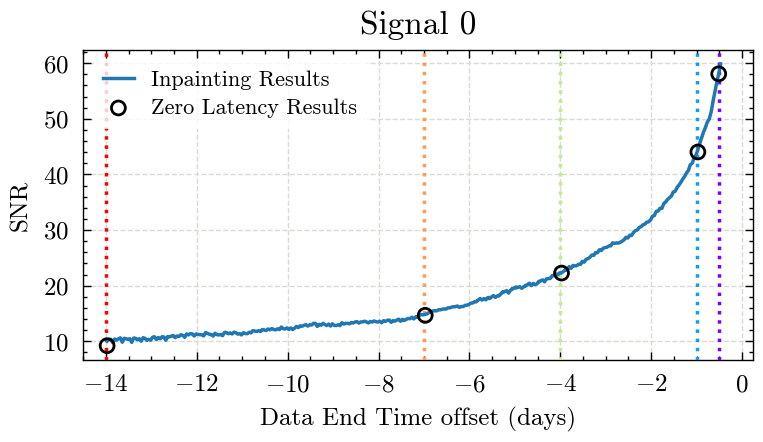

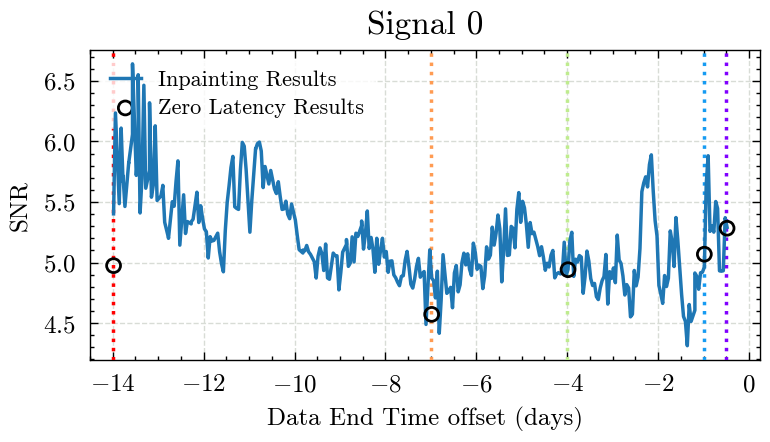

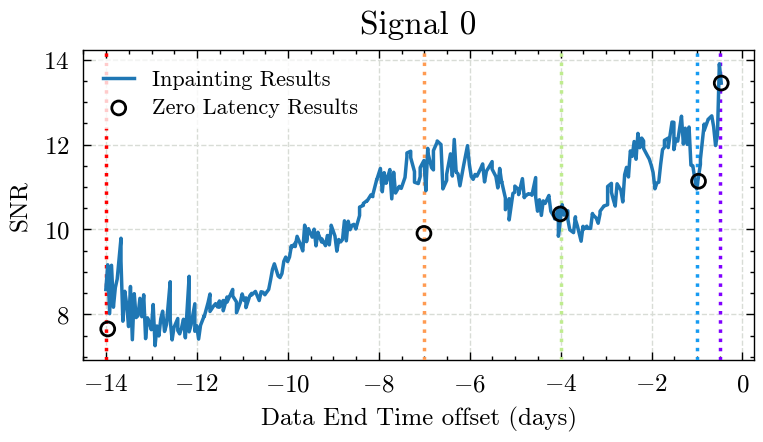

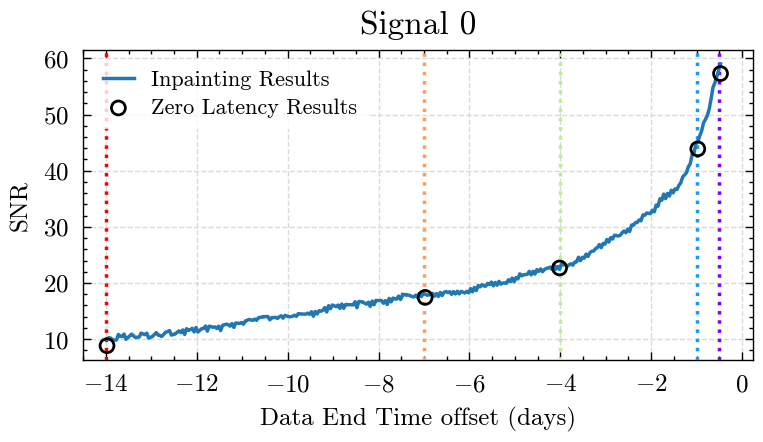

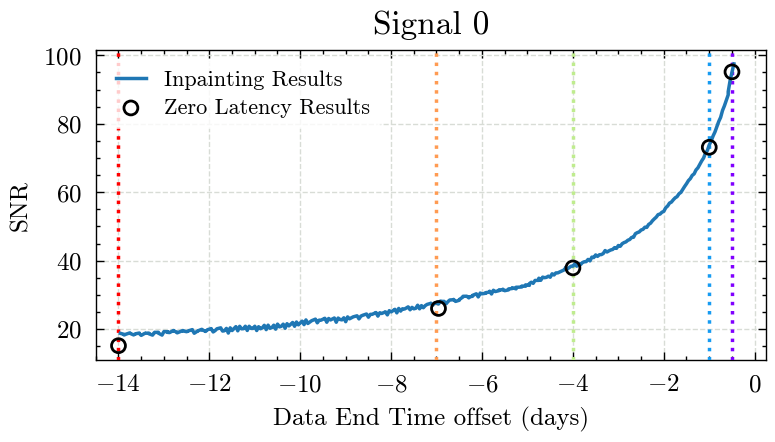

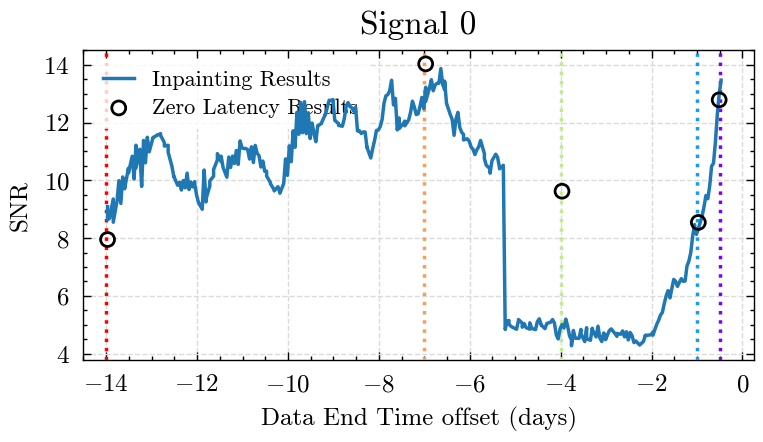

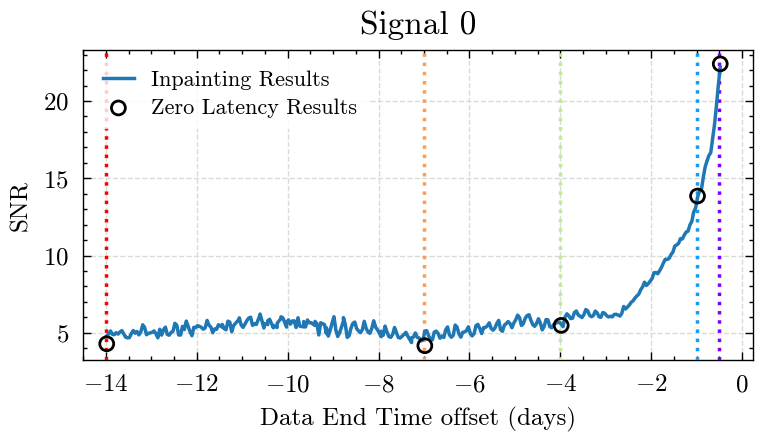

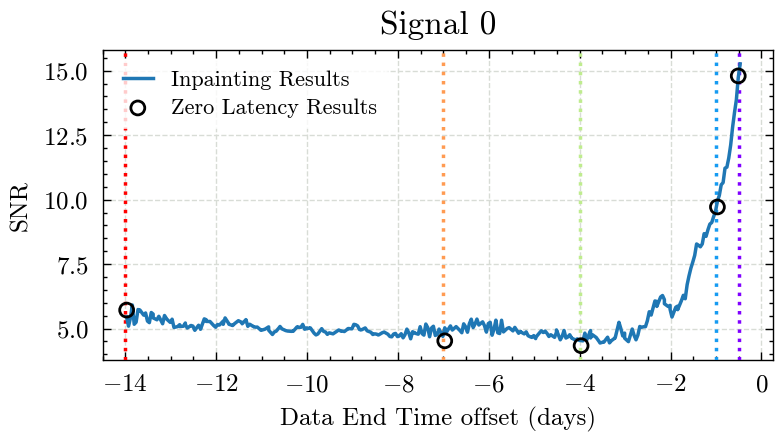

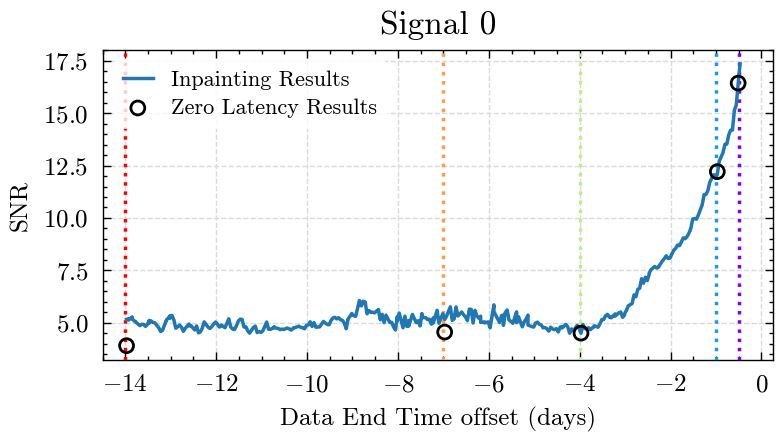

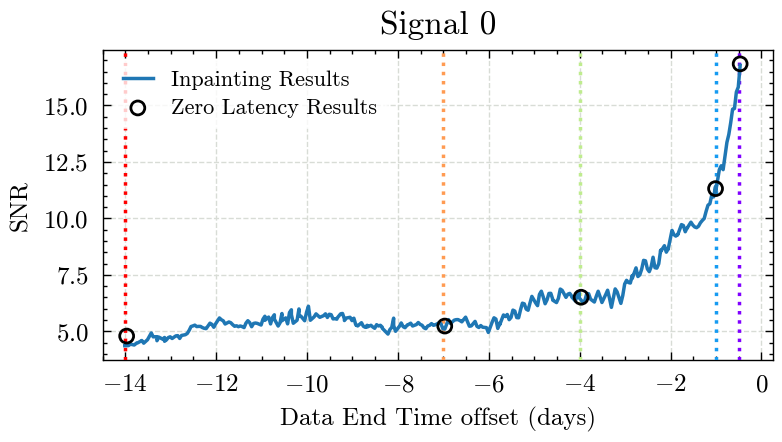

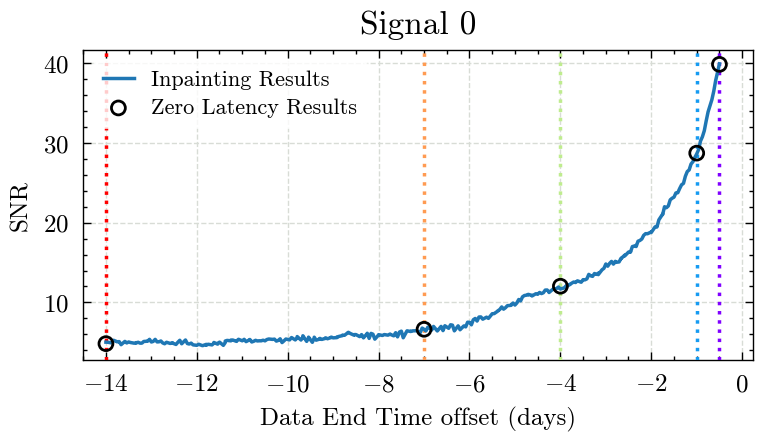

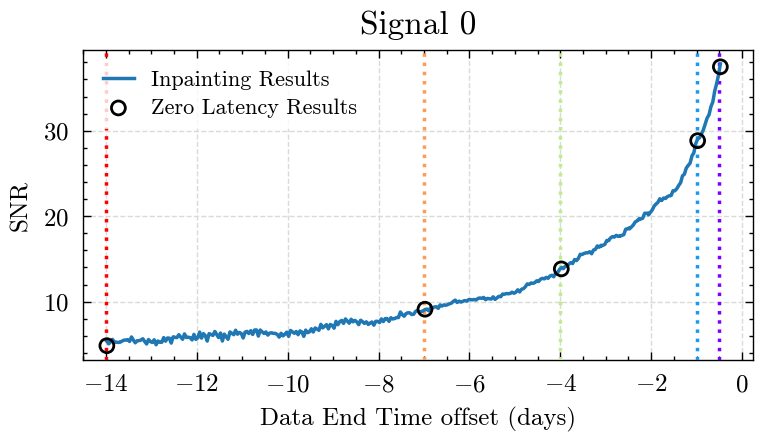

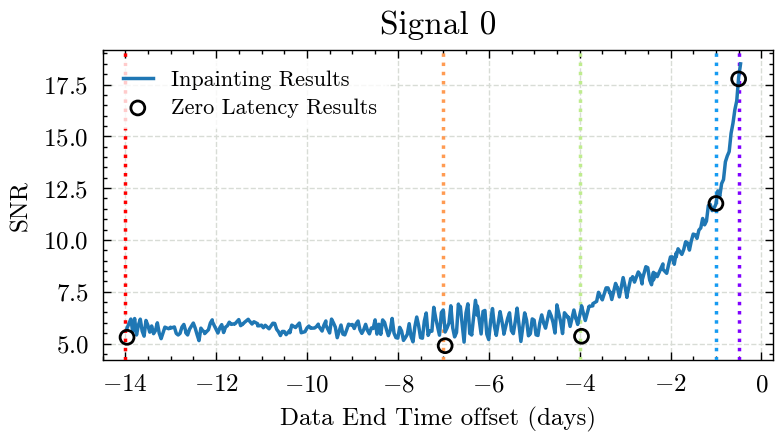

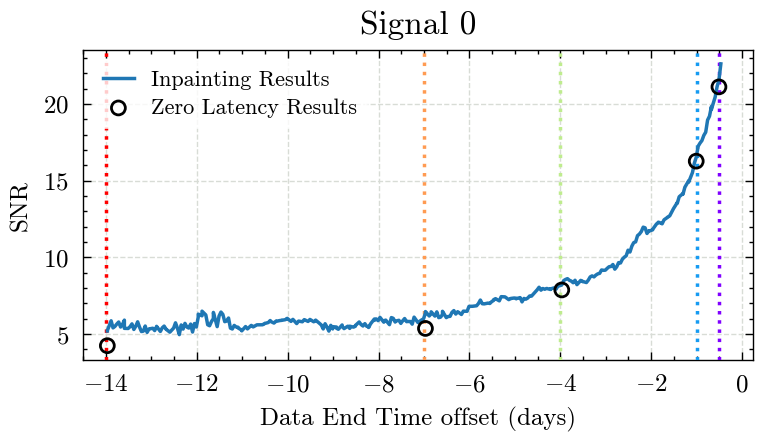

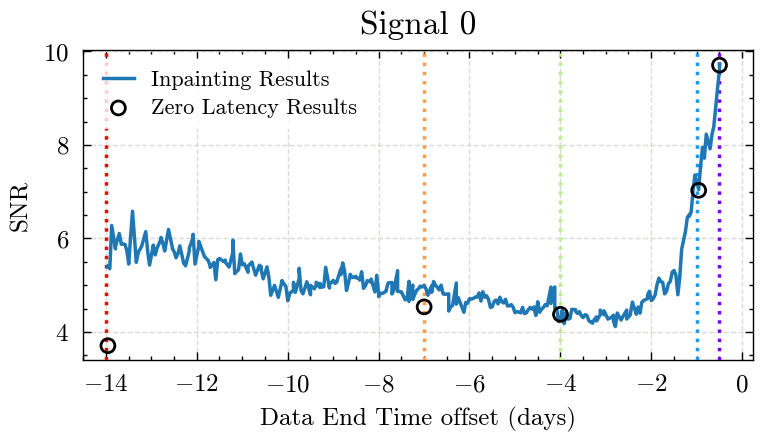

In [17]:

for signal_number in np.arange(15):

    # Filter the zero latency results to only use the closest point for each time before merger
    zl_data_end_time = []
    zl_snr = []

    for t_before in times_before:
        this_t = results_zero_latency['time_before'] == t_before
        closest_match = np.argmin(
            abs(results_zero_latency['time'][this_t] - truth_times_s[signal_number])
        )
        zl_data_end_time.append(results_zero_latency['data_end_time'][this_t][closest_match])
        zl_snr.append(results_zero_latency['snr'][this_t][closest_match])

    zl_data_end_time = np.array(zl_data_end_time)
    zl_snr = np.array(zl_snr)


    ip_times_before = np.unique(results_estimate_all['time_before'])
    ip_data_end_time = []
    ip_snr = []
    for t_before in ip_times_before:
        this_t = results_estimate_all['time_before'] == t_before
        closest_match = np.argmin(
            abs(results_estimate_all['time'][this_t] - truth_times_s[signal_number])
        )
        ip_data_end_time.append(results_estimate_all['data_end_time'][this_t][closest_match])
        ip_snr.append(results_estimate_all['snr'][this_t][closest_match])

    ip_data_end_time = np.array(ip_data_end_time)
    ip_snr = np.array(ip_snr)

    width = plt.rcParams["figure.figsize"][0] * 1.25
    height = plt.rcParams["figure.figsize"][1]

    fig, ax = plt.subplots(1, figsize=(width, height),)

    ax.plot(
        (ip_data_end_time - truth_times_s[signal_number]) / 86400,
        ip_snr,
        linewidth=1.25,
        color='tab:blue',
        label='Inpainting Results',
        zorder=10
    )

    ax.scatter(
        (zl_data_end_time - truth_times_s[signal_number]) / 86400,
        zl_snr,
        edgecolor='k',
        marker='o',
        facecolors='none',
        label='Zero Latency Results',
        zorder=20

    )

    sm = plotting_utils.get_sm(vmin=min(times_before), vmax=max(times_before))

    for time_before in times_before:
        ax.axvline(
            -time_before,
            c=sm.to_rgba(time_before),
            linestyle=':',
            linewidth=1.25,
            zorder=5
        )

    ax.grid(zorder=0)
    ax.set_xlim(-14.5, 0.25)
    ax.set_title(f'Signal {example_signal}')
    ax.legend(loc='upper left')
    ax.set_ylabel('SNR')
    ax.set_xlabel('Data End Time offset (days)')
    fig.show()
    fig.savefig(f'plots/signal_{example_signal}_end_timeline.png')